# ==========================================
# Credit Score Classification Project
# ==========================================

# Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

# Load Dataset

In [5]:
train = pd.read_csv("train.csv")

print("Dataset Shape:", train.shape)
train.head()


Dataset Shape: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


# Drop Irrelevant Columns

In [6]:
drop_cols = ['ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan']

train = train.drop(columns=[col for col in drop_cols if col in train.columns])


# Clean Known Problem Columns

In [7]:
# Clean Annual Income
train['Annual_Income'] = train['Annual_Income'].astype(str).str.replace('_','')
train['Annual_Income'] = pd.to_numeric(train['Annual_Income'], errors='coerce')

# Convert numeric-like columns
train['Outstanding_Debt'] = pd.to_numeric(train['Outstanding_Debt'], errors='coerce')
train['Num_of_Loan'] = pd.to_numeric(train['Num_of_Loan'], errors='coerce')


# Convert Credit History Age to Months

In [8]:
def convert_credit_history(x):
    if pd.isnull(x):
        return np.nan
    try:
        years = int(x.split(' ')[0])
        months = int(x.split(' ')[3])
        return years * 12 + months
    except:
        return np.nan

train['Credit_History_Age'] = train['Credit_History_Age'].apply(convert_credit_history)


# Handle Missing Values

In [9]:
# Fill numeric with median
numeric_cols = train.select_dtypes(include=np.number).columns
train[numeric_cols] = train[numeric_cols].fillna(train[numeric_cols].median())

# Fill categorical with mode
categorical_cols = train.select_dtypes(include='object').columns
for col in categorical_cols:
    train[col] = train[col].fillna(train[col].mode()[0])


# Feature Engineering

In [10]:
train['Debt_to_Income'] = train['Outstanding_Debt'] / (train['Annual_Income'] + 1)
train['EMI_to_Income'] = train['Total_EMI_per_month'] / (train['Annual_Income'] + 1)
train['Utilization_Impact'] = train['Credit_Utilization_Ratio'] * train['Num_of_Loan']


# Encode Categorical Columns

In [11]:
for col in train.select_dtypes(include='object').columns:
    train[col] = train[col].astype(str)
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])


# Exploratory Data Analysis

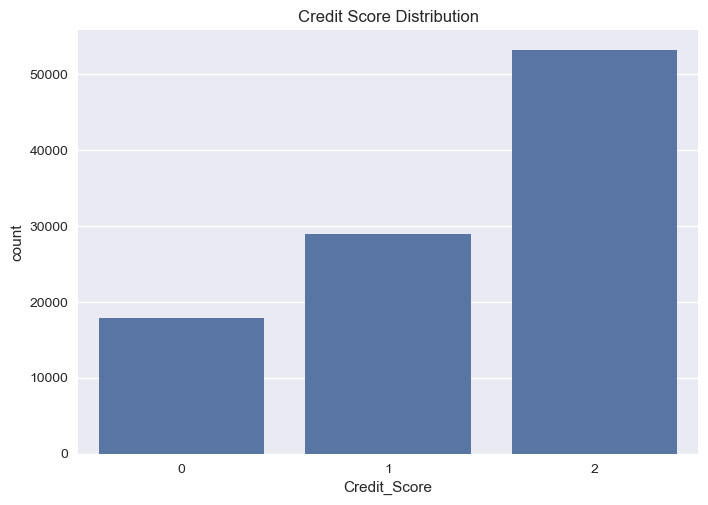

In [12]:
sns.countplot(x='Credit_Score', data=train)
plt.title("Credit Score Distribution")
plt.show()


# Correlation Heatmap

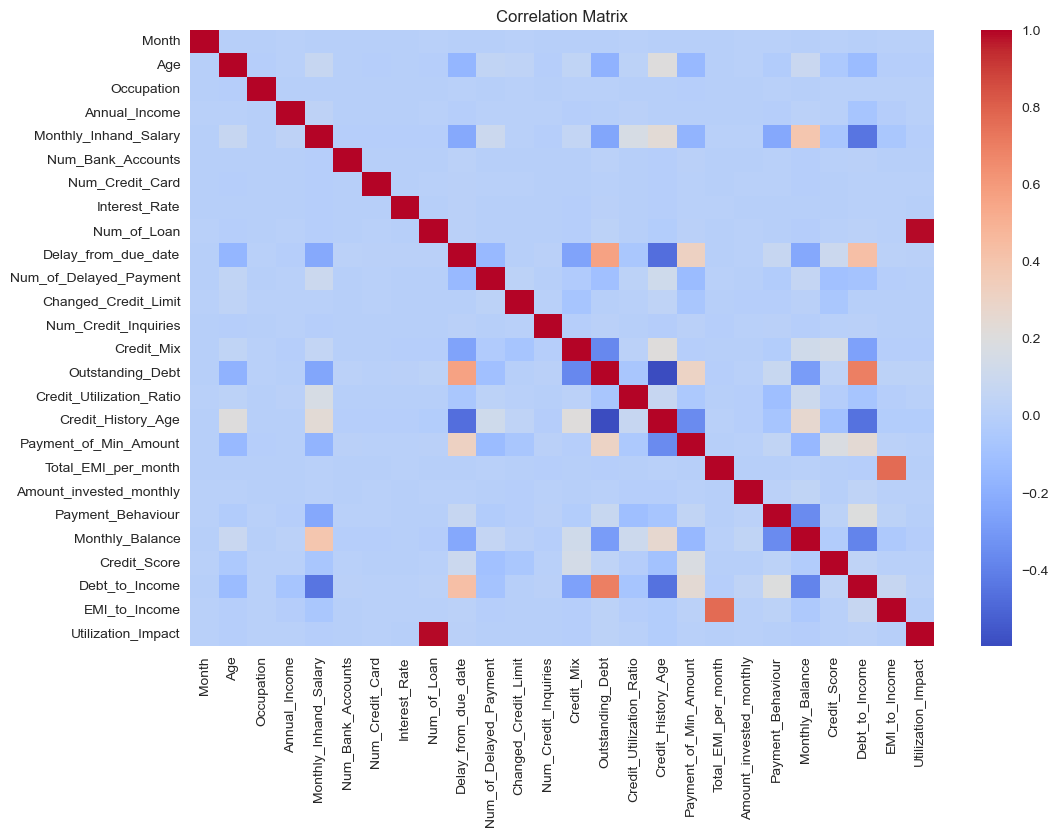

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


# Split Features & Target

In [14]:
X = train.drop("Credit_Score", axis=1)
y = train["Credit_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Train Random Forest (Final Model)

In [15]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Final Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_pred))


Final Random Forest Accuracy: 0.7837
              precision    recall  f1-score   support

           0       0.73      0.72      0.73      3566
           1       0.77      0.79      0.78      5799
           2       0.81      0.80      0.80     10635

    accuracy                           0.78     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.78      0.78      0.78     20000



# Train XGBoost (Comparison Model)

In [16]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)
print(classification_report(y_test, xgb_pred))


XGBoost Accuracy: 0.7702
              precision    recall  f1-score   support

           0       0.71      0.72      0.71      3566
           1       0.77      0.75      0.76      5799
           2       0.79      0.80      0.79     10635

    accuracy                           0.77     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.77      0.77      0.77     20000



# Model Comparison

In [17]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy]
})

comparison


,Model,Accuracy
0,Random Forest,0.7837
1,XGBoost,0.7702


# Confusion Matrix (Final Model)

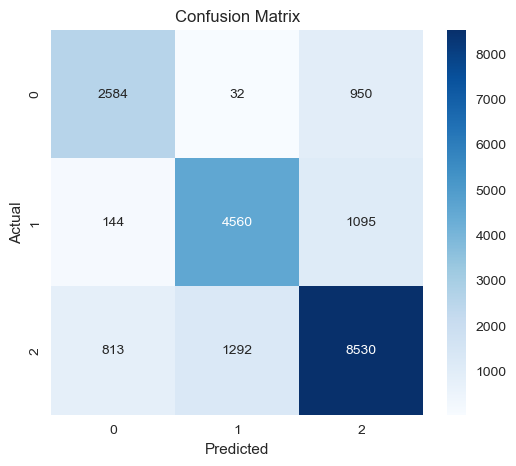

In [18]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Feature Importance

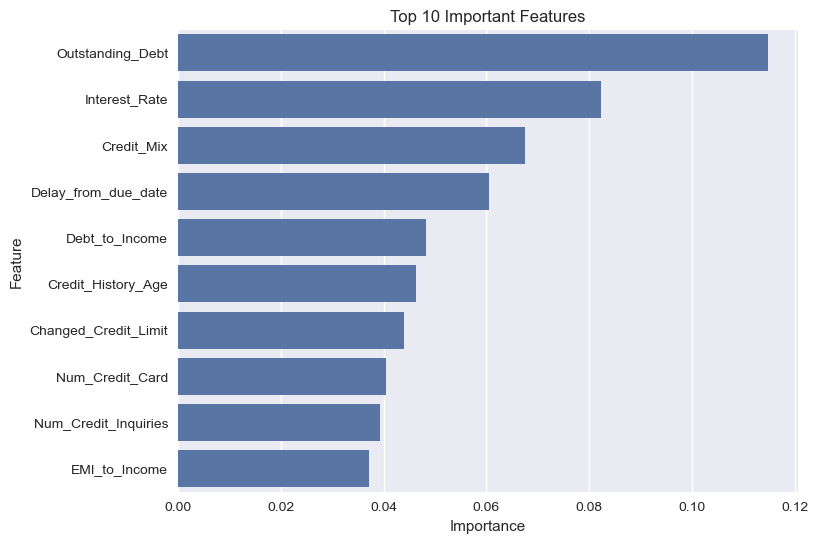

,Feature,Importance
14,Outstanding_Debt,0.114831
7,Interest_Rate,0.082232
13,Credit_Mix,0.067506
9,Delay_from_due_date,0.060517
22,Debt_to_Income,0.048196
16,Credit_History_Age,0.046371
11,Changed_Credit_Limit,0.043910
6,Num_Credit_Card,0.040433
12,Num_Credit_Inquiries,0.039252
23,EMI_to_Income,0.037166


In [19]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

importance_df.head(10)


# Full Clean Dataset (for analysis)

In [21]:
train.to_csv("clean_credit_data.csv", index=False)


# Feature Importance File

In [22]:
importance_df.to_csv("feature_importance.csv", index=False)


# Confusion Matrix File

In [23]:
cm_df = pd.DataFrame(cm)
cm_df.to_csv("confusion_matrix.csv", index=False)


# Save Final Model

In [24]:
joblib.dump(rf, "credit_score_model.pkl")
print("Model Saved Successfully!")


Model Saved Successfully!
